# 🦠 Disease Detection Model Training

**Smart Crop Advisor — AI Module**

This notebook trains a **RandomForestClassifier** to predict crop diseases based on:
- **Crop Name** (label-encoded)
- **Observed Symptoms** (TF-IDF vectorized text)

The trained model is saved as `.pkl` artifacts and served via the FastAPI `/predict/disease` endpoint.

---

### API Contract (from Backend README)

**Input** (sent by Java Spring Boot):
```json
{
  "crop": "Tomato",
  "symptoms": ["yellow leaves", "brown spots"]
}
```

**Output** (expected by Java Spring Boot):
```json
{
  "prediction": "Early Blight"
}
```

---
## Step 1 — Import Libraries

In [1]:
import os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy.sparse import hstack, csr_matrix

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

%matplotlib inline
sns.set_style('whitegrid')
print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 2 — Load Dataset

In [2]:
# Paths
DATA_DIR   = os.path.join('..', 'data')
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

csv_file = os.path.join(DATA_DIR, 'disease_data.csv')
df = pd.read_csv(csv_file)

# Clean whitespace
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f'Dataset Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(10)

Dataset Shape: (3000, 4)
Columns: ['Crop', 'Symptoms', 'Disease', 'Severity']


,Crop,Symptoms,Disease,Severity
0,Banana,Root rot,Panama Disease,Medium
1,Maize,"Brown spots on leaves, Wilting stems",Common Rust,Medium
2,Tomato,"Leaf curl, Yellow leaves, Stunted growth",Leaf Curl,High
3,Rice,"Yellow leaves, Brown spots on leaves",Brown Spot,High
4,Wheat,"White powder on leaves, Yellow leaves",Powdery Mildew,High
5,Rice,"Brown spots on leaves, Black lesions",Blast,Critical
6,Wheat,"Yellow leaves, Stunted growth",Root Rot,Low
7,Rice,Stunted growth,Blast,Medium
8,Wheat,"Yellow leaves, Rusty orange pustules",Leaf Rust,High
9,Tomato,"Yellow leaves, Leaf curl",Leaf Curl,Medium


---
## Step 3 — Dataset Overview

In [3]:
CROP_COL    = 'Crop'
SYMPTOM_COL = 'Symptoms'
TARGET_COL  = 'Disease'

print(f'Target column      : "{TARGET_COL}"')
print(f'Crop column        : "{CROP_COL}"')
print(f'Symptom column     : "{SYMPTOM_COL}"')
print(f'\nTotal rows         : {len(df)}')
print(f'Unique crops       : {df[CROP_COL].nunique()}')
print(f'Unique diseases    : {df[TARGET_COL].nunique()}')
print(f'\nDisease classes    : {sorted(df[TARGET_COL].unique())}')
print(f'Crop classes       : {sorted(df[CROP_COL].unique())}')

Target column      : "Disease"
Crop column        : "Crop"
Symptom column     : "Symptoms"

Total rows         : 3000
Unique crops       : 12
Unique diseases    : 20

Disease classes    : ['Anthracnose', 'Bacterial Blight', 'Black Scurf', 'Black Sigatoka', 'Blast', 'Brown Spot', 'Common Rust', 'Downy Mildew', 'Early Blight', 'Late Blight', 'Leaf Blight', 'Leaf Curl', 'Leaf Rust', 'Leaf Spot', 'Panama Disease', 'Powdery Mildew', 'Red Rot', 'Root Rot', 'Rust', 'Wilt']
Crop classes       : ['Banana', 'Cotton', 'Grapes', 'Groundnut', 'Maize', 'Mango', 'Potato', 'Rice', 'Soybean', 'Sugarcane', 'Tomato', 'Wheat']


In [4]:
# Basic statistics
df.info()
print('\n--- Null values ---')
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Crop      3000 non-null   str  
 1   Symptoms  3000 non-null   str  
 2   Disease   3000 non-null   str  
 3   Severity  3000 non-null   str  
dtypes: str(4)
memory usage: 93.9 KB

--- Null values ---
Crop        0
Symptoms    0
Disease     0
Severity    0
dtype: int64


---
## Step 4 — Exploratory Data Analysis (EDA)

### 4.1 — Disease Class Distribution

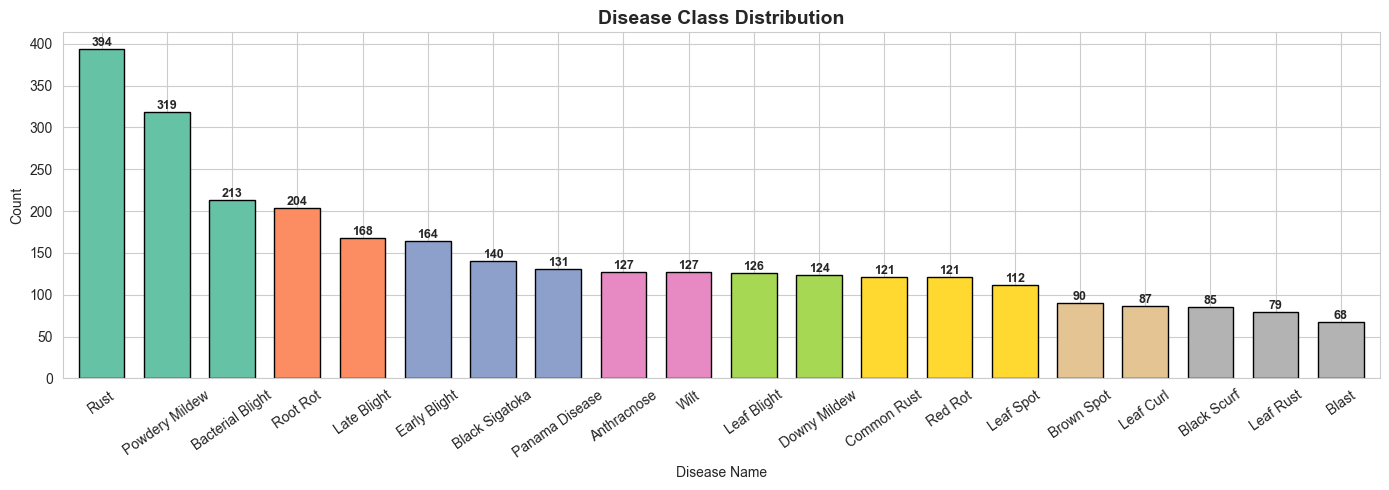

In [5]:
vc = df[TARGET_COL].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(vc)))
vc.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.7)
ax.set_title('Disease Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Disease Name')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'disease_class_dist.png'), dpi=100)
plt.show()

### 4.2 — Crop Distribution

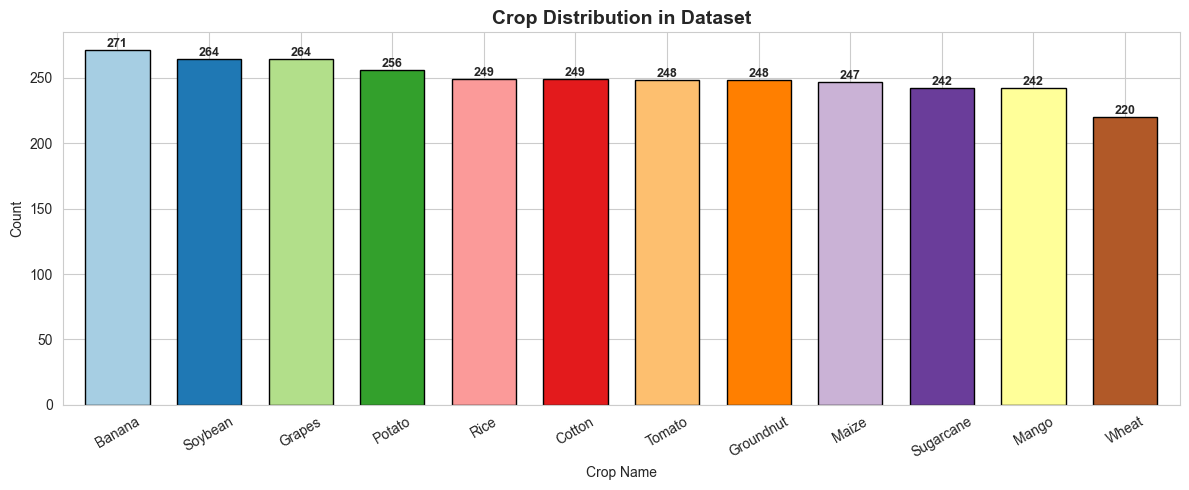

In [6]:
crop_vc = df[CROP_COL].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Paired(np.linspace(0, 1, len(crop_vc)))
crop_vc.plot(kind='bar', ax=ax, color=colors, edgecolor='black', width=0.7)
ax.set_title('Crop Distribution in Dataset', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop Name')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=30)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3 — Crop vs Disease Heatmap

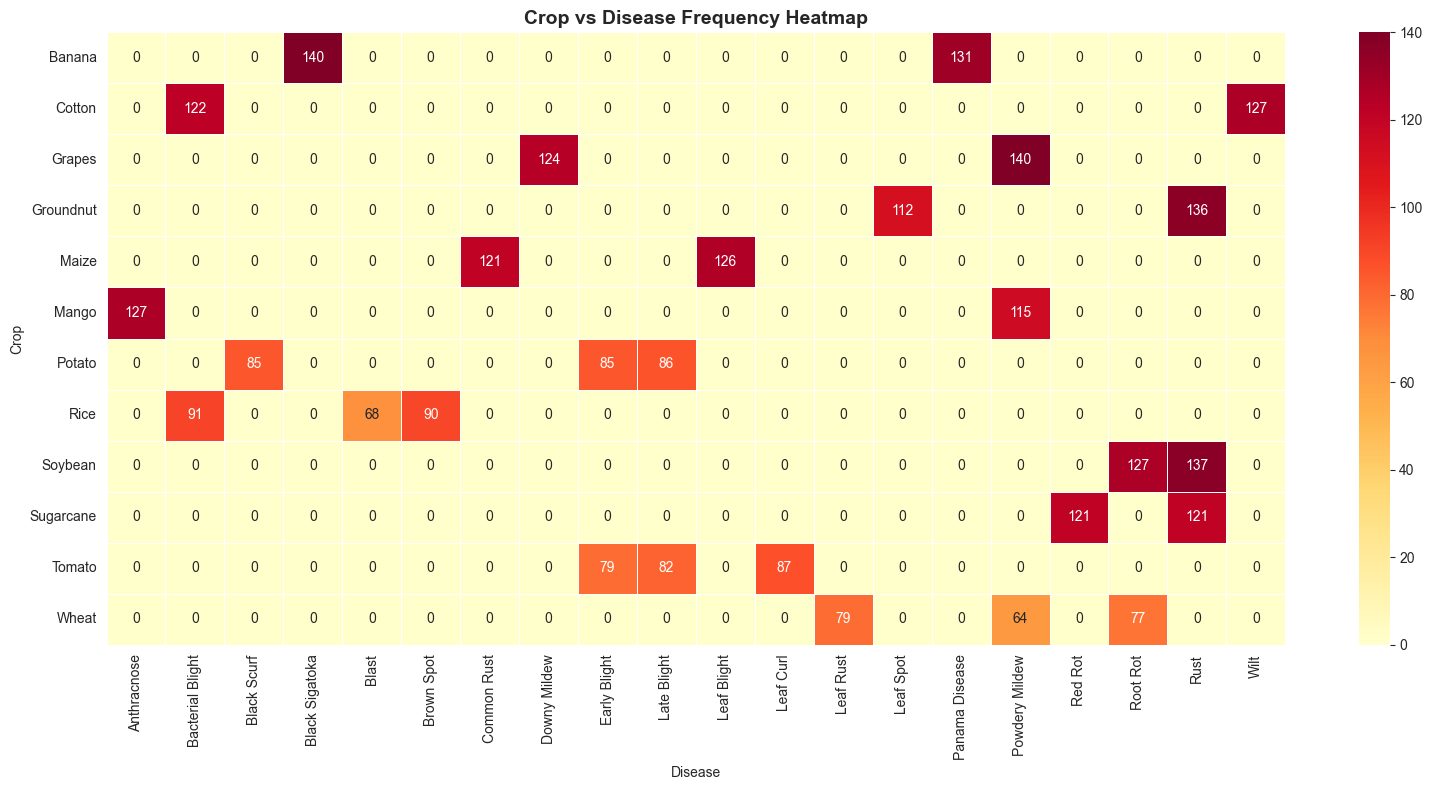

In [7]:
ct = pd.crosstab(df[CROP_COL], df[TARGET_COL])

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, square=False)
ax.set_title('Crop vs Disease Frequency Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'disease_crop_heatmap.png'), dpi=100)
plt.show()

### 4.4 — Severity Distribution

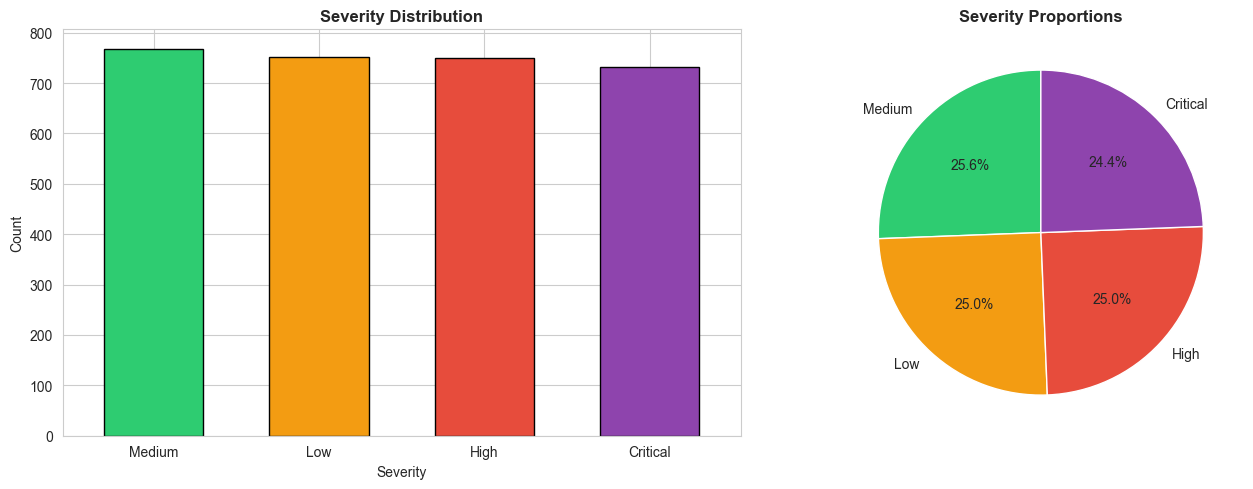

In [8]:
sev_vc = df['Severity'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sev_vc.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
            edgecolor='black', width=0.6)
axes[0].set_title('Severity Distribution', fontweight='bold')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
sev_vc.plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
            colors=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
            startangle=90)
axes[1].set_title('Severity Proportions', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 4.5 — Sample Symptom Analysis

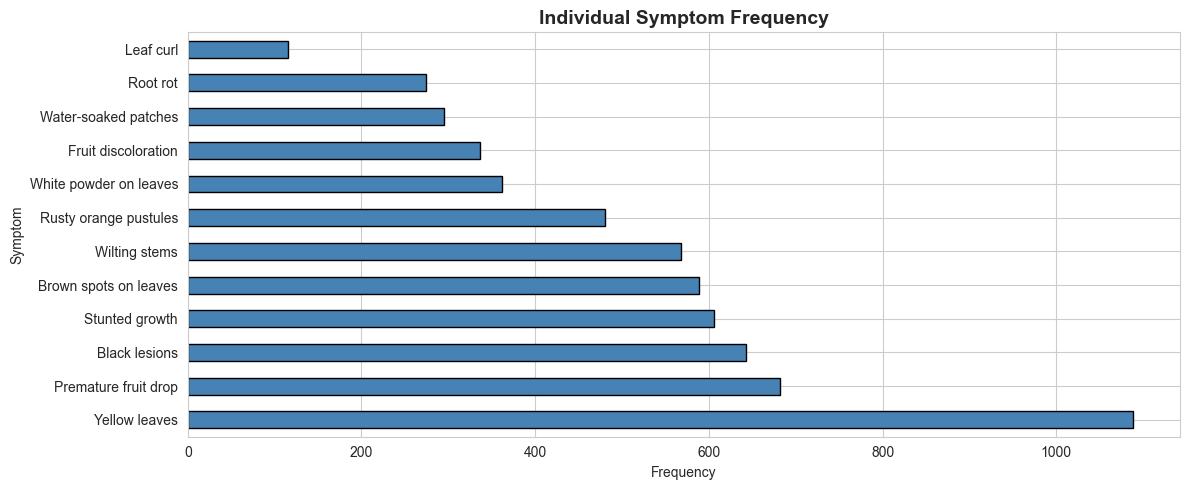


Total unique individual symptoms: 12


In [9]:
# Count how often each individual symptom appears
all_symptoms = df[SYMPTOM_COL].str.split(', ').explode()
symptom_freq = all_symptoms.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
symptom_freq.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Individual Symptom Frequency', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency')
ax.set_ylabel('Symptom')
plt.tight_layout()
plt.show()

print(f'\nTotal unique individual symptoms: {symptom_freq.shape[0]}')

---
## Step 5 — Preprocessing

### 5.1 — Encode Crop Name (LabelEncoder)

In [10]:
crop_encoder = LabelEncoder()
crop_encoded = crop_encoder.fit_transform(df[CROP_COL].astype(str))

print(f'Crop classes: {list(crop_encoder.classes_)}')
print(f'Encoded shape: {crop_encoded.shape}')
print(f'Sample mapping:')
for i, cls in enumerate(crop_encoder.classes_):
    print(f'  {cls:15s} -> {i}')

Crop classes: ['Banana', 'Cotton', 'Grapes', 'Groundnut', 'Maize', 'Mango', 'Potato', 'Rice', 'Soybean', 'Sugarcane', 'Tomato', 'Wheat']
Encoded shape: (3000,)
Sample mapping:
  Banana          -> 0
  Cotton          -> 1
  Grapes          -> 2
  Groundnut       -> 3
  Maize           -> 4
  Mango           -> 5
  Potato          -> 6
  Rice            -> 7
  Soybean         -> 8
  Sugarcane       -> 9
  Tomato          -> 10
  Wheat           -> 11


### 5.2 — Vectorize Symptoms (TF-IDF)

Since symptoms come as comma-separated text (e.g., `"Yellow leaves, Brown spots on leaves"`), we use **TF-IDF vectorization** to convert them into numeric features.

- `ngram_range=(1, 2)` captures single words AND bigrams like "brown spots"
- `max_features=200` limits vocabulary to prevent overfitting
- `stop_words='english'` removes common words like "on", "the"

In [11]:
tfidf = TfidfVectorizer(
    lowercase=True,
    max_features=200,
    ngram_range=(1, 2),
    stop_words='english'
)
symptom_vectors = tfidf.fit_transform(df[SYMPTOM_COL].astype(str))

print(f'TF-IDF vocabulary size: {len(tfidf.vocabulary_)}')
print(f'Symptom vector shape : {symptom_vectors.shape}')
print(f'\nTop 20 TF-IDF features:')
vocab = sorted(tfidf.vocabulary_.items(), key=lambda x: x[1])
for word, idx in vocab[:20]:
    print(f'  [{idx:3d}] {word}')

TF-IDF vocabulary size: 147
Symptom vector shape : (3000, 147)

Top 20 TF-IDF features:
  [  0] black
  [  1] black lesions
  [  2] brown
  [  3] brown spots
  [  4] curl
  [  5] curl premature
  [  6] curl rusty
  [  7] curl stunted
  [  8] curl water
  [  9] curl yellow
  [ 10] discoloration
  [ 11] discoloration black
  [ 12] discoloration brown
  [ 13] discoloration leaf
  [ 14] discoloration premature
  [ 15] discoloration root
  [ 16] discoloration rusty
  [ 17] discoloration stunted
  [ 18] discoloration water
  [ 19] discoloration white


### 5.3 — Combine Features

We horizontally stack the encoded crop column (1 numeric feature) with the TF-IDF symptom vectors (sparse matrix).

In [12]:
crop_sparse = csr_matrix(crop_encoded.reshape(-1, 1).astype(np.float64))
X = hstack([crop_sparse, symptom_vectors])

print(f'Combined feature matrix shape: {X.shape}')
print(f'  - Column 0      : Crop (label-encoded)')
print(f'  - Columns 1-{X.shape[1]-1}  : TF-IDF symptom features')

Combined feature matrix shape: (3000, 148)
  - Column 0      : Crop (label-encoded)
  - Columns 1-147  : TF-IDF symptom features


### 5.4 — Encode Target Variable

In [13]:
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[TARGET_COL].astype(str))

print(f'Target classes ({len(target_encoder.classes_)}):')
for i, cls in enumerate(target_encoder.classes_):
    print(f'  {i:2d} -> {cls}')

Target classes (20):
   0 -> Anthracnose
   1 -> Bacterial Blight
   2 -> Black Scurf
   3 -> Black Sigatoka
   4 -> Blast
   5 -> Brown Spot
   6 -> Common Rust
   7 -> Downy Mildew
   8 -> Early Blight
   9 -> Late Blight
  10 -> Leaf Blight
  11 -> Leaf Curl
  12 -> Leaf Rust
  13 -> Leaf Spot
  14 -> Panama Disease
  15 -> Powdery Mildew
  16 -> Red Rot
  17 -> Root Rot
  18 -> Rust
  19 -> Wilt


---
## Step 6 — Train / Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Testing set  : {X_test.shape[0]} samples')
print(f'Split ratio  : 80% train / 20% test (stratified)')

Training set : 2400 samples
Testing set  : 600 samples
Split ratio  : 80% train / 20% test (stratified)


---
## Step 7 — Baseline Model & Cross-Validation

In [15]:
print('Training baseline RandomForest (n_estimators=100)...')
baseline_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_rf.fit(X_train, y_train)

baseline_acc = accuracy_score(y_test, baseline_rf.predict(X_test))
print(f'Baseline Test Accuracy: {baseline_acc * 100:.2f}%')

Training baseline RandomForest (n_estimators=100)...
Baseline Test Accuracy: 89.17%


In [16]:
# 5-Fold Stratified Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(baseline_rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

print(f'5-Fold CV Scores: {[f"{s*100:.2f}%" for s in cv_scores]}')
print(f'Mean CV Accuracy: {cv_scores.mean() * 100:.2f}% +/- {cv_scores.std() * 100:.2f}%')

5-Fold CV Scores: ['87.67%', '89.33%', '92.00%', '88.00%', '89.50%']
Mean CV Accuracy: 89.30% +/- 1.53%


---
## Step 8 — Hyperparameter Tuning (GridSearchCV)

In [17]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features'     : ['sqrt', 'log2']
}

print(f'Parameter grid: {len(param_grid["n_estimators"])} x {len(param_grid["max_depth"])} x '
      f'{len(param_grid["min_samples_split"])} x {len(param_grid["max_features"])} '
      f'= {3*3*2*2} combinations')
print(f'With 5-fold CV = {3*3*2*2*5} total fits\n')

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f'\nBest Parameters : {grid_search.best_params_}')
print(f'Best CV Score   : {grid_search.best_score_ * 100:.2f}%')

Parameter grid: 3 x 3 x 2 x 2 = 36 combinations
With 5-fold CV = 180 total fits

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best Parameters : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score   : 88.67%


---
## Step 9 — Evaluation on Test Set

In [18]:
y_pred   = grid_search.best_estimator_.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print('=' * 55)
print(f'  TEST SET ACCURACY : {test_acc * 100:.2f}%')
print('=' * 55)

  TEST SET ACCURACY : 88.83%


In [19]:
# Detailed Classification Report
print('Classification Report:\n')
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

Classification Report:

                  precision    recall  f1-score   support

     Anthracnose       0.92      0.92      0.92        25
Bacterial Blight       0.93      0.88      0.90        43
     Black Scurf       0.81      0.76      0.79        17
  Black Sigatoka       0.96      0.96      0.96        28
           Blast       1.00      0.71      0.83        14
      Brown Spot       0.68      0.94      0.79        18
     Common Rust       0.95      0.88      0.91        24
    Downy Mildew       1.00      0.92      0.96        25
    Early Blight       0.85      0.88      0.87        33
     Late Blight       0.90      0.79      0.84        34
     Leaf Blight       0.91      0.84      0.88        25
       Leaf Curl       0.88      0.88      0.88        17
       Leaf Rust       0.92      0.75      0.83        16
       Leaf Spot       0.79      0.68      0.73        22
  Panama Disease       0.96      1.00      0.98        26
  Powdery Mildew       0.88      0.94      0.91

### 9.1 — Confusion Matrix

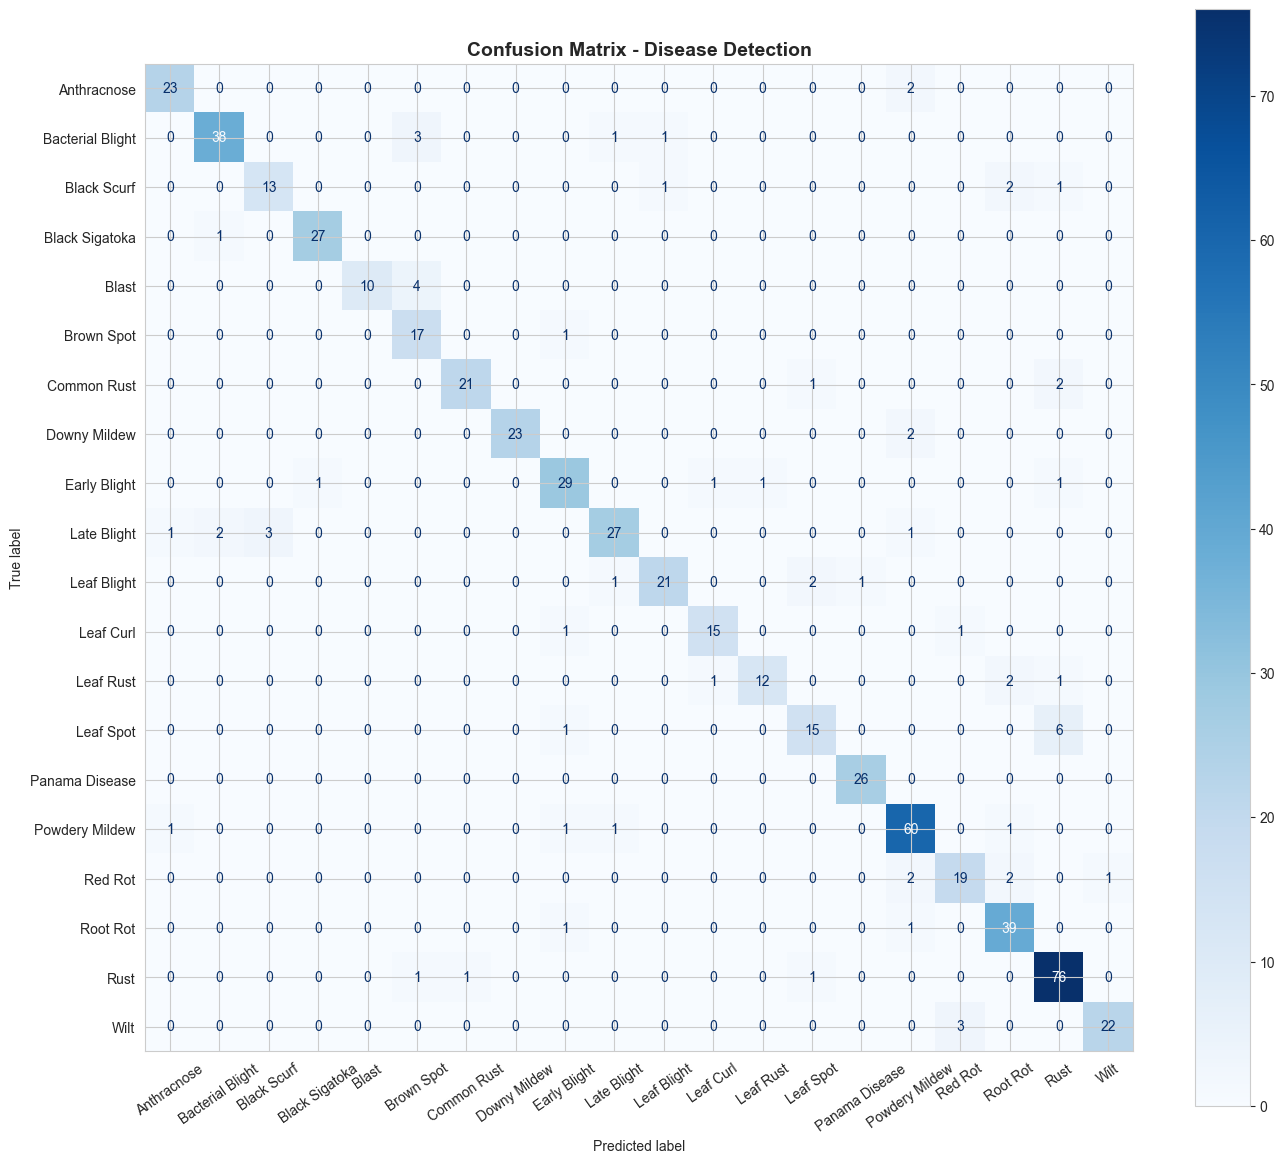

In [20]:
fig, ax = plt.subplots(figsize=(14, 12))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=35)
ax.set_title('Confusion Matrix - Disease Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(MODELS_DIR, 'disease_confusion_matrix.png'), dpi=100)
plt.show()

---
## Step 10 — Retrain Final Model on 100% Data

For production deployment, we retrain the best model configuration on the **entire dataset** (not just the 80% training split) to maximize learning.

In [21]:
best_params = grid_search.best_params_
print(f'Retraining with best params: {best_params}')

final_model = RandomForestClassifier(**best_params, random_state=42, n_jobs=-1)
final_model.fit(X, y)

print(f'Final model retrained on {X.shape[0]} samples (100% data)')

Retraining with best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Final model retrained on 3000 samples (100% data)


---
## Step 11 — Save Model Artifacts

The following `.pkl` files are saved to `ai/models/` and loaded by `app.py` at startup:

| File | Purpose |
|---|---|
| `disease_model.pkl` | The trained RandomForest classifier |
| `disease_crop_encoder.pkl` | LabelEncoder for crop names |
| `disease_tfidf.pkl` | TF-IDF vectorizer for symptom text |
| `disease_target_encoder.pkl` | LabelEncoder for disease names (inverse_transform for prediction) |
| `disease_model_metadata.pkl` | Metadata dict with params, accuracy, class lists |

In [22]:
# Save all artifacts
joblib.dump(final_model,    os.path.join(MODELS_DIR, 'disease_model.pkl'))
joblib.dump(crop_encoder,   os.path.join(MODELS_DIR, 'disease_crop_encoder.pkl'))
joblib.dump(tfidf,          os.path.join(MODELS_DIR, 'disease_tfidf.pkl'))
joblib.dump(target_encoder, os.path.join(MODELS_DIR, 'disease_target_encoder.pkl'))
joblib.dump({
    'crop_column'          : CROP_COL,
    'symptom_column'       : SYMPTOM_COL,
    'target_column'        : TARGET_COL,
    'target_classes'       : list(target_encoder.classes_),
    'crop_classes'         : list(crop_encoder.classes_),
    'best_params'          : best_params,
    'test_accuracy_pct'    : round(test_acc * 100, 2),
    'cv_mean_accuracy_pct' : round(cv_scores.mean() * 100, 2),
    'tfidf_vocab_size'     : len(tfidf.vocabulary_),
}, os.path.join(MODELS_DIR, 'disease_model_metadata.pkl'))

print('All artifacts saved successfully!')
print(f'\nFiles in models/ (disease-related):')
for f in sorted(os.listdir(MODELS_DIR)):
    if 'disease' in f.lower():
        size_kb = os.path.getsize(os.path.join(MODELS_DIR, f)) / 1024
        print(f'  {f:<45} {size_kb:>8.1f} KB')

All artifacts saved successfully!

Files in models/ (disease-related):
  disease_class_dist.png                            56.2 KB
  disease_confusion_matrix.png                     118.8 KB
  disease_crop_encoder.pkl                           0.6 KB
  disease_crop_heatmap.png                          72.5 KB
  disease_model.pkl                              48044.4 KB
  disease_model_metadata.pkl                         0.8 KB
  disease_target_encoder.pkl                         0.7 KB
  disease_tfidf.pkl                                  6.9 KB


---
## Step 12 — Quick Inference Test

Simulate exactly what the FastAPI `/predict/disease` endpoint does when the backend sends a request.

In [23]:
# Simulate API input from backend
test_crop     = "Tomato"
test_symptoms = ["Yellow leaves", "Brown spots on leaves"]

# Step 1: Encode crop
crop_enc = crop_encoder.transform([test_crop])[0]
crop_sp  = csr_matrix([[float(crop_enc)]])

# Step 2: Vectorize symptoms (join list into comma-separated string)
symptom_text = ", ".join(test_symptoms)
symptom_vec  = tfidf.transform([symptom_text])

# Step 3: Combine features
features = hstack([crop_sp, symptom_vec])

# Step 4: Predict
prediction = final_model.predict(features)
disease    = target_encoder.inverse_transform(prediction)[0]

print(f'Input  -> crop: "{test_crop}", symptoms: {test_symptoms}')
print(f'Output -> prediction: "{disease}"')
print(f'\nThis matches the backend contract: {{"prediction": "{disease}"}}')

Input  -> crop: "Tomato", symptoms: ['Yellow leaves', 'Brown spots on leaves']
Output -> prediction: "Early Blight"

This matches the backend contract: {"prediction": "Early Blight"}


In [24]:
# Test with more examples
test_cases = [
    ("Rice",   ["Water-soaked patches", "Wilting stems", "Yellow leaves"]),
    ("Wheat",  ["White powder on leaves"]),
    ("Potato", ["Black lesions", "Water-soaked patches"]),
    ("Mango",  ["Black lesions", "Fruit discoloration", "Premature fruit drop"]),
    ("Banana", ["Yellow leaves", "Root rot"]),
]

print(f'{"Crop":<12} {"Symptoms":<55} {"Predicted Disease"}')
print('-' * 90)

for crop, symptoms in test_cases:
    c_enc = crop_encoder.transform([crop])[0]
    c_sp  = csr_matrix([[float(c_enc)]])
    s_vec = tfidf.transform([", ".join(symptoms)])
    feat  = hstack([c_sp, s_vec])
    pred  = target_encoder.inverse_transform(final_model.predict(feat))[0]
    print(f'{crop:<12} {", ".join(symptoms):<55} {pred}')

Crop         Symptoms                                                Predicted Disease
------------------------------------------------------------------------------------------
Rice         Water-soaked patches, Wilting stems, Yellow leaves      Bacterial Blight
Wheat        White powder on leaves                                  Powdery Mildew
Potato       Black lesions, Water-soaked patches                     Late Blight
Mango        Black lesions, Fruit discoloration, Premature fruit drop Anthracnose
Banana       Yellow leaves, Root rot                                 Panama Disease


---
## Training Summary

| Metric | Value |
|---|---|
| **Algorithm** | RandomForestClassifier |
| **Features** | Crop (LabelEncoded) + Symptoms (TF-IDF) |
| **Disease Classes** | 20 |
| **Dataset Size** | 3,000 rows |
| **Train/Test Split** | 80/20 (stratified) |
| **Hyperparameter Tuning** | GridSearchCV (36 combos x 5 folds) |

### Saved Artifacts
- `disease_model.pkl` — Trained classifier
- `disease_crop_encoder.pkl` — Crop LabelEncoder
- `disease_tfidf.pkl` — Symptom TF-IDF vectorizer
- `disease_target_encoder.pkl` — Disease LabelEncoder
- `disease_model_metadata.pkl` — Training metadata